In [29]:
from scipy import integrate 
import numpy as np
import matplotlib.pyplot as plt 

### part 1

c:\Users\amani\Downloads\SURP\actually_cta\a3.py:20: RuntimeWarning: overflow encountered in square
  z=z**2+c # vectorized calculation of z[i,j] * z[i,j] + c[i,j]
c:\Users\amani\Downloads\SURP\actually_cta\a3.py:20: RuntimeWarning: invalid value encountered in square
  z=z**2+c # vectorized calculation of z[i,j] * z[i,j] + c[i,j]


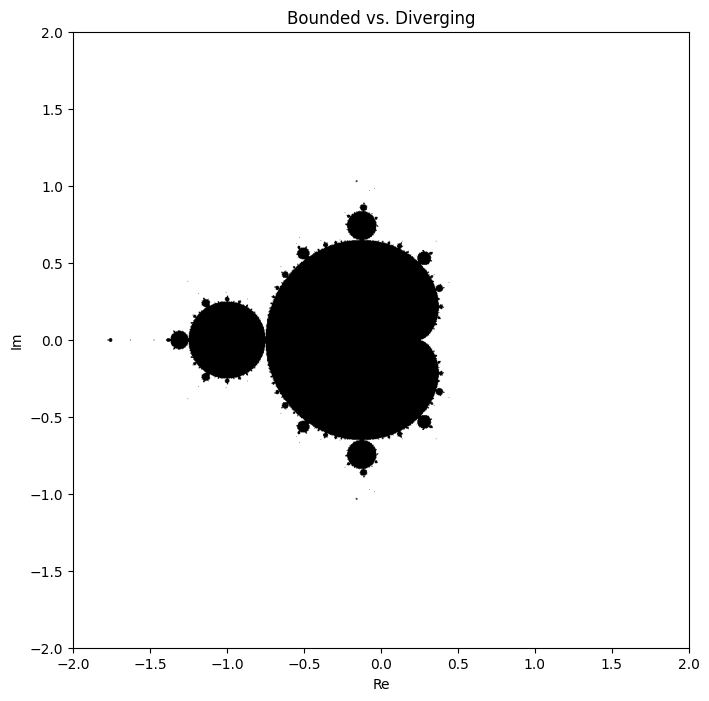

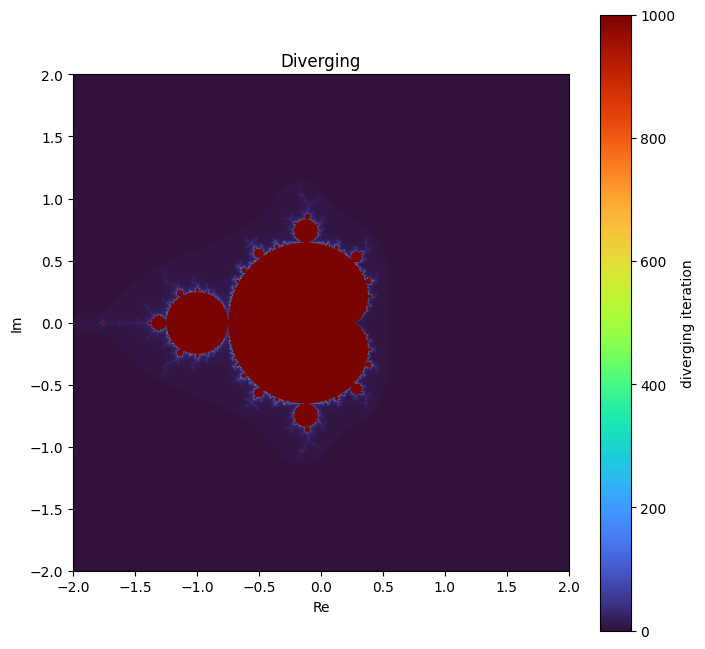

In [30]:

# %run -i a3.py
import a3

bounded, diverging = a3.bounded_and_diverging()

# first image
plt.figure(figsize=(8,8))
plt.imshow(bounded, extent=(-2,2,-2,2), origin='lower', cmap='binary')

plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Bounded vs. Diverging")
plt.savefig("bounded vs diverging.pdf")

# second image
plt.figure(figsize=(8,8))
plt.imshow(diverging, extent=(-2,2,-2,2), origin='lower', cmap='turbo')
plt.colorbar(label='diverging iteration')

plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Diverging")
plt.savefig("diverging.pdf")



### part 2

<small>

In [31]:
# equations
def lorenz(t, W, prandtl, rayleigh, b):
    """
    Calculate the derivatives for Lorenz's equations.

    Parameters:
    t: float
        time variable for ODE solver
    W: tuple, list of floats
        initial conditions 
    prandtl: float
        prandlt number
    rayleigh: float
        rayleigh number
    b: float
        dimensionless length scale

    Returns:
    tuple of floats
        the derivatives dxdt, dydt and dzdt

    """

    X, Y, Z = W
    dxdt = -(prandtl)*(X-Y)
    dydt = rayleigh*X - Y - X*Z
    dzdt = -b*Z+X*Y
    return (dxdt, dydt, dzdt)


In [32]:
# parameters
W0 = (0.0, 1.0, 0.0)
prandtl = 10.0
r = 28.0
b = 8.0/3.0
t_span = (0.0, 60.0) # solve from t=0-60

t_eval = np.linspace(0, 60.0, 3000) # sol sampled at 3000 evenly spaced times

# integrate equations 
integral = integrate.solve_ivp(lorenz, t_span, W0, args=(prandtl, r, b), t_eval=t_eval)

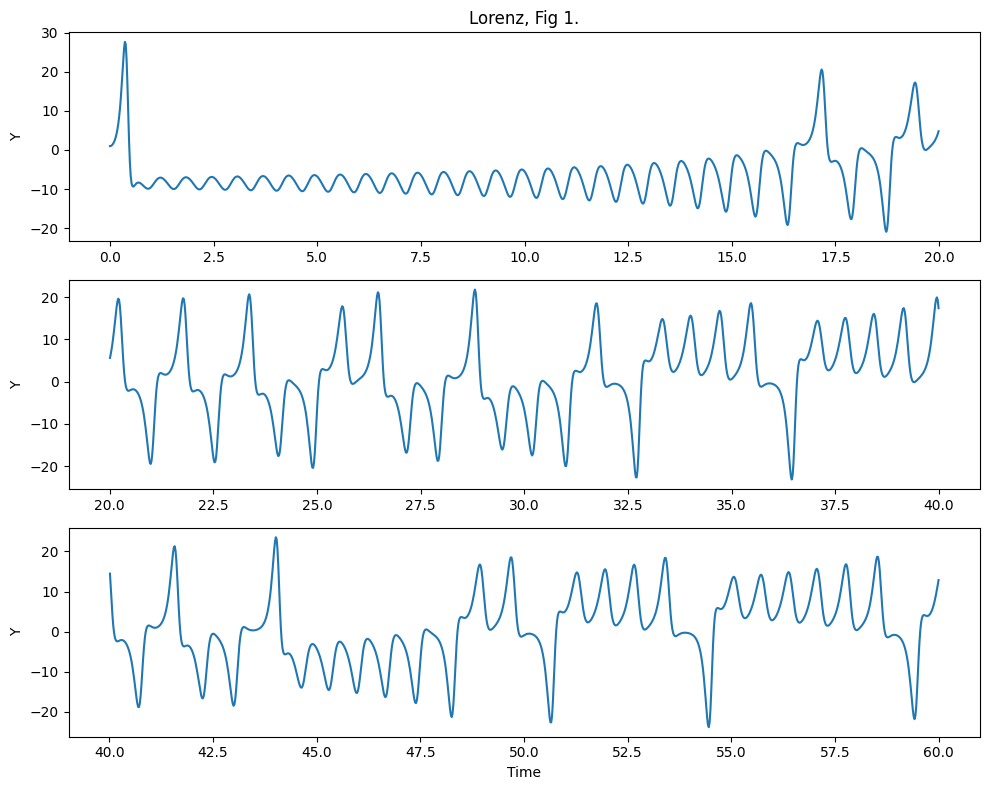

In [33]:
# make figure 1

t = integral.t
x = integral.y[0]
y = integral.y[1] # index 1 contains y
z = integral.y[2]

# stacked plots
fig, ax = plt.subplots(3,1,figsize=(10,8))

ax[0].set_title("Lorenz, Fig 1.")

ax[0].plot(t[:1000], y[:1000]) # 1000 iter
ax[0].set_ylabel("Y")
ax[1].plot(t[1000:2000], y[1000:2000]) # 1000 iter
ax[1].set_ylabel("Y")
ax[2].plot(t[2000:3000], y[2000:3000]) # 1000 iter
ax[2].set_ylabel("Y")
ax[2].set_xlabel("Time")

plt.tight_layout()
plt.savefig("lorenz1.pdf")
plt.show()



note: the only way i could get my figures to match Fig 2. in Lorenz was by inverting the horizontal axes, though this was not in the instructions

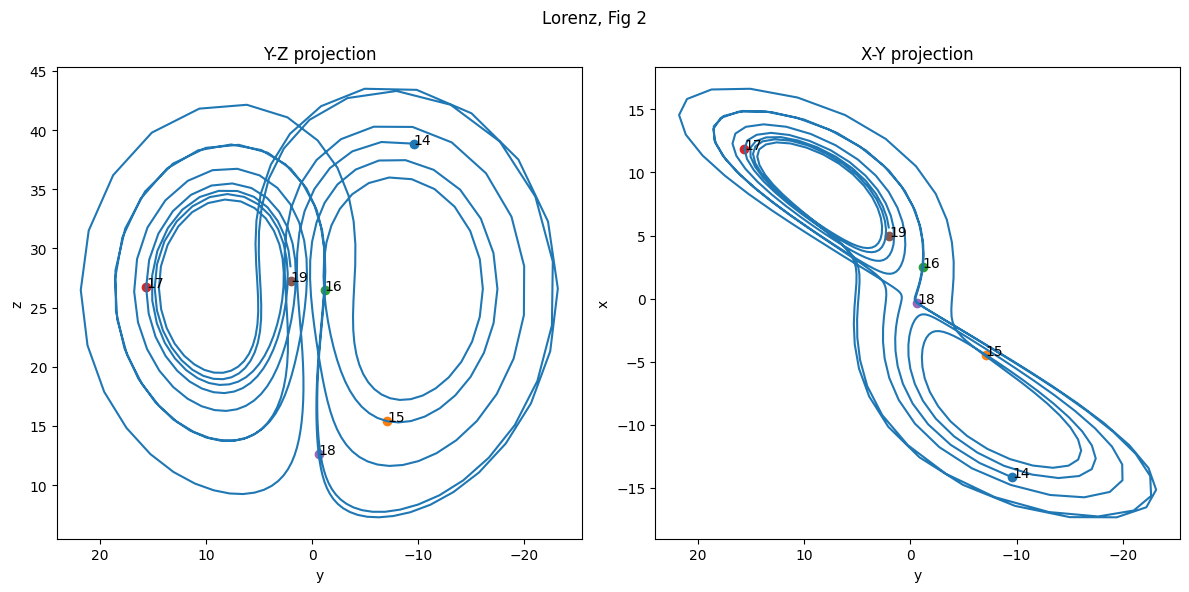

In [34]:
# make figure 2

t_eval2 = np.linspace(14, 19, 1000)
# integrate equations 
integral = integrate.solve_ivp(lorenz, t_span, W0, args=(prandtl, r, b), t_eval=t_eval2)

start, stop = 1400, 1900

annotations = range(1400, 1901, 100) # start, stop not included, interval

fig, ax = plt.subplots(1,2,figsize=(12,6))

fig.suptitle("Lorenz, Fig 2")

# first part - YZ-projection
ax[0].plot(y[start:stop], z[start:stop])
for i in annotations:
    ax[0].scatter(y[i], z[i])
    ax[0].text(y[i], z[i], str(i//100))

ax[0].set_xlabel("y")
ax[0].set_ylabel("z")
ax[0].set_title("Y-Z projection")
ax[0].invert_xaxis()

# second part - XY-projection
ax[1].plot(y[start:stop], x[start:stop])

for i in annotations:
    ax[1].scatter(y[i], x[i])
    ax[1].text(y[i], x[i], str(i//100))

ax[1].set_xlabel("y")
ax[1].set_ylabel("x")
ax[1].set_title("X-Y projection")
ax[1].invert_xaxis()


plt.tight_layout()
plt.savefig("lorenz2.pdf")
plt.show()



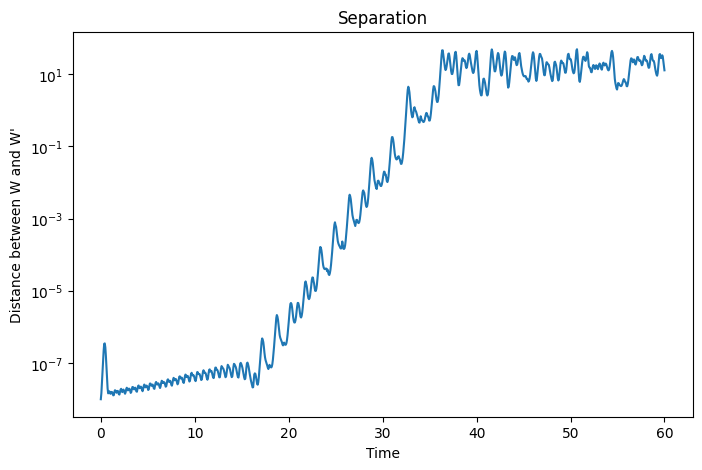

In [35]:
# final plot

W0_prime = np.asarray(W0) + np.asarray([0, 1e-8, 0])

# solve again
t_eval = np.linspace(0, 60.0, 1000)
integral = integrate.solve_ivp(lorenz, t_span, W0, args=(prandtl, r, b), t_eval=t_eval)
integral2 = integrate.solve_ivp(lorenz, t_span, W0_prime, args=(prandtl, r, b), t_eval=t_eval)

# distances
pos1 = integral.y
pos2 = integral2.y

posx, posy, posz = (pos2-pos1) # transpose to unpack x,y,z differences
distance = np.sqrt((posx**2+posy**2+posz**2))

# plot figure 
plt.figure(figsize=(8,5))
plt.semilogy(integral.t, distance)

plt.title("Separation")
plt.xlabel("Time")
plt.ylabel("Distance between W and W'")
plt.savefig("lorenz3.pdf")
plt.show()

